In [3]:
import pandas as pd 

print("Loading full dataset...")
df_full = pd.read_csv('UserBehavior.csv',
    names=['User_ID', 'Product_ID', 'Category_ID', 'Behavior', 'Timestamp'])

print(f"Full dataset: {df_full.shape}")

# ============================================
# Smart Certified Sample
# مستخدمين عندهم 15+ تفاعل
# ============================================
user_counts  = df_full.groupby('User_ID').size()
active_users = user_counts[user_counts >= 15].index

print(f"\nUsers with 15+ interactions: {active_users.shape[0]:,}")

# نأخذ sample عشوائية من هاي المستخدمين
sample_users = pd.Series(active_users).sample(n=20000, random_state=42)
df_smart     = df_full[df_full['User_ID'].isin(sample_users)]

print(f"\n=== Smart Certified Sample ===")
print(f"Users    : {df_smart['User_ID'].nunique():,}")
print(f"Rows     : {len(df_smart):,}")
print(f"Avg/User : {len(df_smart)/df_smart['User_ID'].nunique():.1f}")
print(f"Buy count: {(df_smart['Behavior']=='buy').sum():,}")
print(f"\nBehavior Distribution:")
print(df_smart['Behavior'].value_counts(normalize=True)*100)

# احفظ
df_smart.to_csv('smart_certified_sample.csv', index=False)
print("\n✅ Smart Certified Sample saved!")

Loading full dataset...
Full dataset: (100150807, 5)

Users with 15+ interactions: 939,456

=== Smart Certified Sample ===
Users    : 20,000
Rows     : 2,112,743
Avg/User : 105.6
Buy count: 42,003

Behavior Distribution:
Behavior
pv      89.573696
cart     5.578625
fav      2.859600
buy      1.988079
Name: proportion, dtype: float64

✅ Smart Certified Sample saved!


Loading datasets...
Full dataset : 100,150,807 rows
Sample       : 926,439 rows


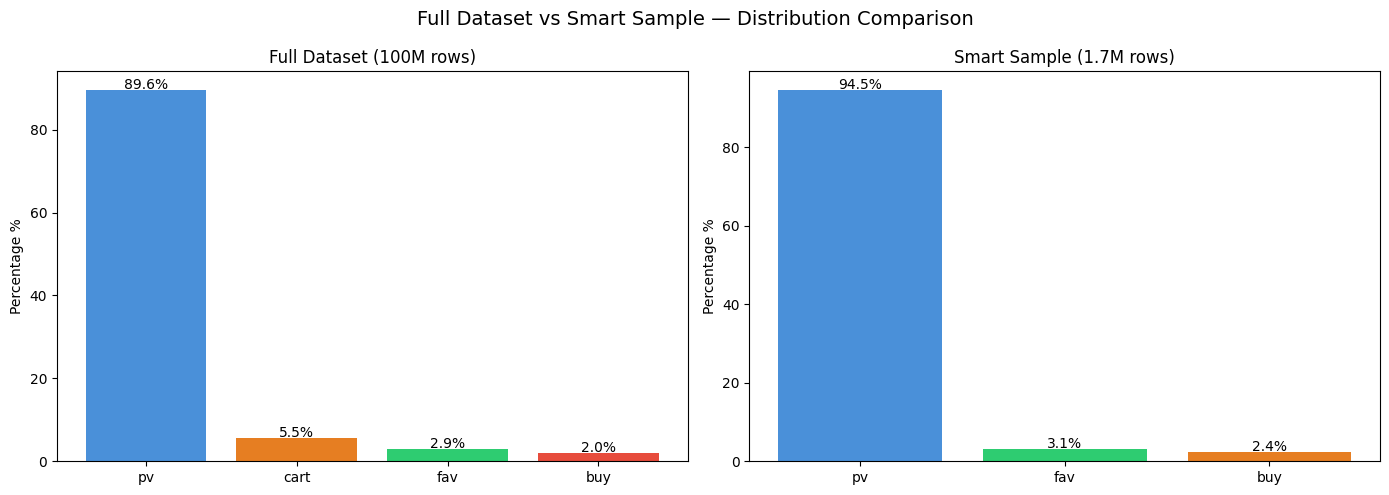

✅ Plot 1 done!


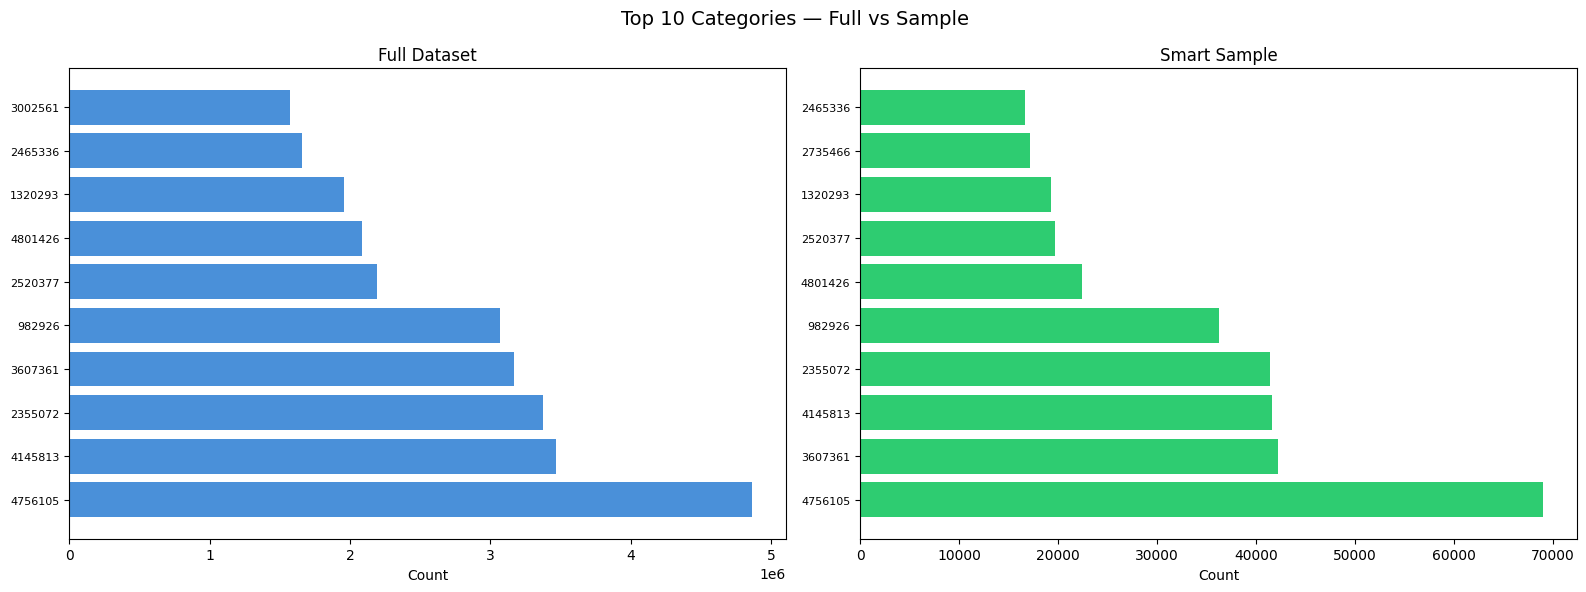

✅ Plot 2 done!

=== Distribution Comparison Table ===
Metric                       Full Dataset    Smart Sample   Difference
----------------------------------------------------------------------
pv rate                            89.58%          94.55%        4.97%
fav rate                            2.88%           3.08%        0.19%
buy rate                            2.01%           2.37%        0.36%

Unique Categories                   9,439           2,895
Total Rows                    100,150,807         926,439


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# Load Both Datasets
# ============================================
print("Loading datasets...")
df_full   = pd.read_csv('UserBehavior.csv',
    names=['User_ID', 'Product_ID', 'Category_ID', 'Behavior', 'Timestamp'])
df_sample = pd.read_csv('smart_filtered.csv')

print(f"Full dataset : {len(df_full):,} rows")
print(f"Sample       : {len(df_sample):,} rows")

# ============================================
# Plot 1: Behavior Distribution Comparison
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Full Dataset vs Smart Sample — Distribution Comparison', fontsize=14)

# Full
full_behavior = df_full['Behavior'].value_counts(normalize=True) * 100
axes[0].bar(full_behavior.index, full_behavior.values, 
            color=['#4A90D9','#E67E22','#2ECC71','#E74C3C'])
axes[0].set_title('Full Dataset (100M rows)')
axes[0].set_ylabel('Percentage %')
for i, v in enumerate(full_behavior.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# Sample
sample_behavior = df_sample['Behavior'].value_counts(normalize=True) * 100
axes[1].bar(sample_behavior.index, sample_behavior.values,
            color=['#4A90D9','#2ECC71','#E67E22'])
axes[1].set_title('Smart Sample (1.7M rows)')
axes[1].set_ylabel('Percentage %')
for i, v in enumerate(sample_behavior.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('comparison_behavior.png', dpi=150)
plt.show()
print("✅ Plot 1 done!")

# ============================================
# Plot 2: Top 10 Categories Comparison
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Categories — Full vs Sample', fontsize=14)

full_cats   = df_full['Category_ID'].value_counts().head(10)
sample_cats = df_sample['Category_ID'].value_counts().head(10)

axes[0].barh(range(10), full_cats.values, color='#4A90D9')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(full_cats.index.astype(str), fontsize=8)
axes[0].set_title('Full Dataset')
axes[0].set_xlabel('Count')

axes[1].barh(range(10), sample_cats.values, color='#2ECC71')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(sample_cats.index.astype(str), fontsize=8)
axes[1].set_title('Smart Sample')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('comparison_categories.png', dpi=150)
plt.show()
print("✅ Plot 2 done!")

# ============================================
# Comparison Table
# ============================================
print("\n=== Distribution Comparison Table ===")
print(f"{'Metric':<25} {'Full Dataset':>15} {'Smart Sample':>15} {'Difference':>12}")
print("-" * 70)

# Behavior rates
for behavior in ['pv', 'fav', 'buy']:
    full_pct   = (df_full['Behavior'] == behavior).sum() / len(df_full) * 100
    if behavior in df_sample['Behavior'].values:
        sample_pct = (df_sample['Behavior'] == behavior).sum() / len(df_sample) * 100
    else:
        sample_pct = 0
    diff = abs(full_pct - sample_pct)
    print(f"{behavior+' rate':<25} {full_pct:>14.2f}% {sample_pct:>14.2f}% {diff:>11.2f}%")

print(f"\n{'Unique Categories':<25} {df_full['Category_ID'].nunique():>15,} {df_sample['Category_ID'].nunique():>15,}")
print(f"{'Total Rows':<25} {len(df_full):>15,} {len(df_sample):>15,}")